# Smart Finance - Análise de Comportamento Financeiro

# Treinamento dos Modelos

## Objetivo

Treinar os dois modelos de Machine Learning utilizados no projeto.

Modelo 1

- Classificação automática das transações

Modelo 2

- Classificação do perfil financeiro


In [43]:
# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS - MODELO 1
# ==========================================================

import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [44]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [45]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Hackatona G9 Finance AI/data"
BASE_MODELS = "/content/drive/MyDrive/Hackatona G9 Finance AI/models"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import os

BASE_MODELS = "/content/drive/MyDrive/Hackatona G9 Finance AI/models"
os.makedirs(BASE_MODELS, exist_ok=True)

In [47]:
  # ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS - MODELO 2
# ==========================================================

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

In [48]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

#dataset_perfil = pd.read_csv(

#    "data/model/dataset_modelo_perfil.csv"

#)

In [49]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

dataset_perfil = pd.read_csv(
    f"{BASE}/model/dataset_modelo_perfil.csv"
)

In [50]:
# ==========================================================
# VARIÁVEL ALVO
# ==========================================================

y = dataset_perfil["perfil_financeiro"]

In [51]:
# ==========================================================
# FEATURES UTILIZADAS
# ==========================================================

X = dataset_perfil.drop(

    columns=[

        "usuario_id",

        "perfil_financeiro",

        "cidade",

        "estado",

        "profissao"

    ]

)

In [52]:
# ==========================================================
# COLUNAS CATEGÓRICAS
# ==========================================================

categoricas = [

    "sexo",

    "estado_civil",

    "escolaridade",

    "frequencia_poupanca"

]

In [53]:
# ==========================================================
# COLUNAS NUMÉRICAS
# ==========================================================

numericas = [

    coluna

    for coluna in X.columns

    if coluna not in categoricas

]

In [54]:
# ==========================================================
# ONE HOT ENCODER
# ==========================================================

preprocessador = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categoricas

        )

    ],

    remainder="passthrough"

)

In [55]:
# ==========================================================
# DIVISÃO TREINO / TESTE
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [56]:
# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline(

    [

        (

            "preprocessamento",

            preprocessador

        ),

        (

            "modelo",

            RandomForestClassifier(

                n_estimators=300,

                max_depth=15,

                min_samples_split=5,

                min_samples_leaf=2,

                random_state=42

            )

        )

    ]

)

In [57]:
# ==========================================================
# TREINAMENTO
# ==========================================================

pipeline.fit(

    X_train,

    y_train

)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sexo', 'estado_civil',
                                                   'escolaridade',
                                                   'frequencia_poupanca'])])),
                ('modelo',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

In [58]:
# ==========================================================
# PREDIÇÕES
# ==========================================================

predicoes = pipeline.predict(

    X_test

)

In [59]:
# ==========================================================
# MÉTRICAS
# ==========================================================

accuracy = accuracy_score(y_test, predicoes)

precision = precision_score(
    y_test,
    predicoes,
    average="macro"
)

recall = recall_score(
    y_test,
    predicoes,
    average="macro"
)

f1 = f1_score(
    y_test,
    predicoes,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000


In [60]:
# ==========================================================
# AVALIAÇÃO TREINO x TESTE
# ==========================================================

acc_treino = pipeline.score(

    X_train,

    y_train

)

acc_teste = pipeline.score(

    X_test,

    y_test

)

print(f"Acurácia Treino : {acc_treino:.4f}")

print(f"Acurácia Teste  : {acc_teste:.4f}")

Acurácia Treino : 1.0000
Acurácia Teste  : 1.0000


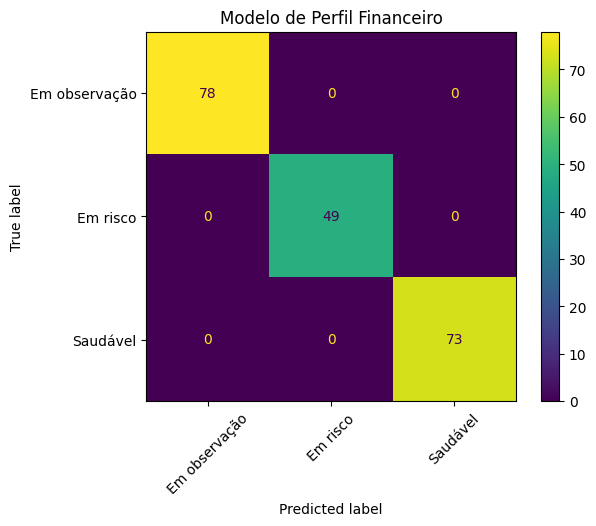

In [61]:
# ==========================================================
# MATRIZ DE CONFUSÃO
# ==========================================================

ConfusionMatrixDisplay.from_predictions(

    y_test,

    predicoes,

    xticks_rotation=45

)

plt.title(

    "Modelo de Perfil Financeiro"

)

plt.show()

In [62]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(

classification_report(

    y_test,

    predicoes,

    digits=4

)

)

               precision    recall  f1-score   support

Em observação     1.0000    1.0000    1.0000        78
     Em risco     1.0000    1.0000    1.0000        49
     Saudável     1.0000    1.0000    1.0000        73

     accuracy                         1.0000       200
    macro avg     1.0000    1.0000    1.0000       200
 weighted avg     1.0000    1.0000    1.0000       200



In [63]:
# ==========================================================
# SALVANDO O MODELO 2
# ==========================================================

joblib.dump(

    pipeline,

    f"{BASE_MODELS}/modelo_perfil.joblib"

)

print(

"Modelo salvo com sucesso."

)

Modelo salvo com sucesso.


In [64]:
# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

modelo_rf = pipeline.named_steps["modelo"]

preprocessador = pipeline.named_steps["preprocessamento"]

In [65]:
# ==========================================================
# NOMES DAS FEATURES APÓS O ONE-HOT ENCODER
# ==========================================================

nomes_features = preprocessador.get_feature_names_out()

importancias = modelo_rf.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": nomes_features,

    "Importancia": importancias

})

feature_importance = feature_importance.sort_values(

    by="Importancia",

    ascending=False

)

feature_importance.head(20)

,Feature,Importancia
21,remainder__nivel_endividamento,0.218497
22,remainder__score_credito,0.187077
25,remainder__percentual_renda_investida,0.171012
23,remainder__saldo_medio_conta,0.095428
24,remainder__limite_cartao,0.043474
67,remainder__perc_cartão de crédito,0.035086
56,remainder__perc_investimentos,0.032976
43,remainder__gasto_investimentos,0.031455
65,remainder__qtd_parceladas,0.019933
71,remainder__perc_pix,0.015487


In [66]:
# ==========================================================
# TOP 20 VARIÁVEIS MAIS IMPORTANTES
# ==========================================================

print(feature_importance.head(20))

                                    Feature  Importancia
21           remainder__nivel_endividamento     0.218497
22                 remainder__score_credito     0.187077
25    remainder__percentual_renda_investida     0.171012
23             remainder__saldo_medio_conta     0.095428
24                 remainder__limite_cartao     0.043474
67        remainder__perc_cartão de crédito     0.035086
56            remainder__perc_investimentos     0.032976
43           remainder__gasto_investimentos     0.031455
65                remainder__qtd_parceladas     0.019933
71                      remainder__perc_pix     0.015487
15          cat__frequencia_poupanca_Sempre     0.014849
13           cat__frequencia_poupanca_Nunca     0.013587
53                  remainder__perc_compras     0.012507
40                 remainder__gasto_compras     0.012017
68         remainder__perc_cartão de débito     0.009459
12  cat__frequencia_poupanca_Frequentemente     0.005725
20                 remainder__o

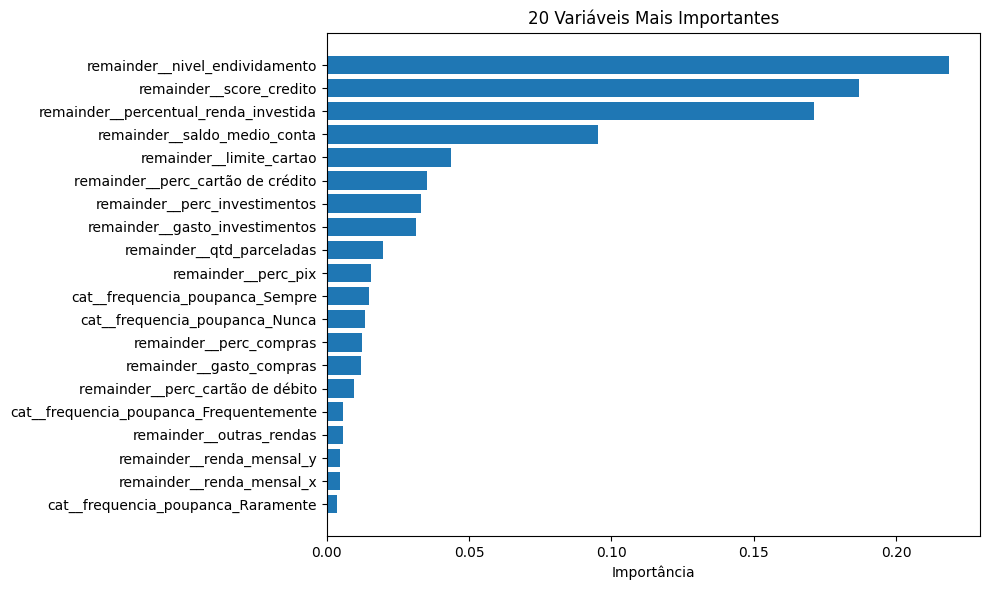

In [67]:
# ==========================================================
# GRÁFICO DAS IMPORTÂNCIAS
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance["Feature"].head(20),

    feature_importance["Importancia"].head(20)

)

plt.gca().invert_yaxis()

plt.title("20 Variáveis Mais Importantes")

plt.xlabel("Importância")

plt.tight_layout()

plt.show()

In [68]:
# ==========================================================
# VALIDAÇÃO CRUZADA
# ==========================================================

scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=cv,

    scoring="f1_macro"

)

print("========== Validação Cruzada ==========")

print(f"F1 Macro por Fold: {scores}")

print(f"F1 Macro Médio: {scores.mean():.4f}")

print(f"Desvio Padrão: {scores.std():.4f}")

========== Validação Cruzada ==========
F1 Macro por Fold: [1. 1. 1. 1. 1.]
F1 Macro Médio: 1.0000
Desvio Padrão: 0.0000


In [69]:
# ============================================================
# EXPORTAR IMPORTÂNCIA DAS FEATURES
# ============================================================

feature_importance.to_csv(
    f"{BASE_MODELS}/feature_importance.csv",
    index=False,
    encoding="utf-8"
)

# Conclusão

## Objetivo alcançado

Neste notebook foram treinados e avaliados os dois modelos de Machine Learning responsáveis pelo núcleo inteligente da aplicação.

### Modelo 1 — Classificação de Transações

Foi desenvolvido um modelo baseado em **TF-IDF** e **Multinomial Naive Bayes**, responsável por classificar automaticamente descrições de transações em suas respectivas categorias financeiras.

Foram realizadas:

- Vetorização textual utilizando TF-IDF;
- Divisão entre treino e teste;
- Treinamento do modelo;
- Avaliação por Accuracy, Precision, Recall e F1-Score;
- Matriz de Confusão;
- Classification Report;
- Validação Cruzada (Stratified K-Fold);
- Serialização do modelo (.joblib).

---

### Modelo 2 — Perfil Financeiro

Foi desenvolvido um modelo baseado em **Random Forest**, responsável por classificar automaticamente o perfil financeiro do usuário.

Foram realizadas:

- Seleção das variáveis;
- One-Hot Encoding das variáveis categóricas;
- Divisão entre treino e teste;
- Treinamento do modelo;
- Avaliação por Accuracy, Precision, Recall e F1-Score;
- Matriz de Confusão;
- Classification Report;
- Validação Cruzada (Stratified K-Fold);
- Análise de Overfitting;
- Importância das Variáveis (Feature Importance);
- Serialização do modelo (.joblib).

---

## Arquivos gerados

Ao final deste notebook foram gerados:

```

models/

modelo_categoria.joblib

modelo_perfil.joblib

tfidf.joblib

feature_importance.csv

```

Esses arquivos serão utilizados pelo backend para realizar inferências durante a execução da API REST.

---